In [1]:
!pip install stable-baselines3[extra]
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git
!pip install websockets>=15.0.0 --quiet
!pip install transformers --quiet
!pip install polygon-api-client --quiet
!pip install alpaca-py --quiet

zsh:1: no matches found: stable-baselines3[extra]
  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-req-build-3d1nkq_k
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-req-build-3d1nkq_k
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit f4283de63ca73c915321c5555fa3751698a61eec
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-install-q62vw3ds/elegantrl_0071ee87ac9640adb963f0be4dacc022
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /private/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/pip-install-q62v

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import pkg_resources
import os
import pickle
from datetime import timedelta, date
from polygon import RESTClient
from transformers import BertTokenizer, BertForSequenceClassification

# Alpaca imports
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest, GetAssetsRequest
from alpaca.trading.enums import OrderSide, TimeInForce, AssetClass

import torch as th
import torch.nn as nn
import stable_baselines3
import finrl

from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.config import INDICATORS

%matplotlib inline
plt.close('all')

print(f"SB3 Version:    {stable_baselines3.__version__}")
print(f"FinRL Version:  {pkg_resources.get_distribution('finrl').version}")
print(f"CUDA Available: {th.cuda.is_available()}")

# ── Mac GPU (Metal / MPS) detection ──────────────────────────────────────────
if th.backends.mps.is_available():
    DEVICE = th.device('mps')
    print("MPS (Apple Metal GPU) available — using GPU ✓")
elif th.cuda.is_available():
    DEVICE = th.device('cuda')
    print(f"CUDA GPU available — using {th.cuda.get_device_name(0)} ✓")
else:
    DEVICE = th.device('cpu')
    print("No GPU found — falling back to CPU")

print(f"Active device: {DEVICE}")

/var/folders/sc/40gcq14x2cng8czg1s_vpkbr0000gn/T/ipykernel_14941/922811064.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SB3 Version:    2.8.0a2
FinRL Version:  0.3.8
CUDA Available: False
MPS (Apple Metal GPU) available — using GPU ✓
Active device: mps


In [ ]:
# ============================================================
# CELL 2a — Alpaca Configuration
# ============================================================

# ── Paste your Alpaca paper trading keys here ────────────────
ALPACA_API_KEY    = "YOUR_API_KEY"
ALPACA_SECRET_KEY = "YOUR_API_KEY"
POLYGON_API_KEY   = os.environ.get('POLYGON_API_KEY', 'YOUR_API_KEY')

# Paper trading = True, Live trading = False
PAPER_TRADING = True

# ── Initialise clients ────────────────────────────────────────
# Data client — used for fetching historical & live price data
data_client = StockHistoricalDataClient(
    api_key=ALPACA_API_KEY,
    secret_key=ALPACA_SECRET_KEY
)

# Trading client — used for placing and managing orders
trading_client = TradingClient(
    api_key=ALPACA_API_KEY,
    secret_key=ALPACA_SECRET_KEY,
    paper=PAPER_TRADING
)

# Verify connection
account = trading_client.get_account()
print(f"Alpaca account connected ✅")
print(f"  Account status:  {account.status}")
print(f"  Buying power:    ${float(account.buying_power):,.2f}")
print(f"  Cash:            ${float(account.cash):,.2f}")
print(f"  Paper trading:   {PAPER_TRADING}")

Alpaca account connected ✅
  Account status:  AccountStatus.ACTIVE
  Buying power:    $200,000.00
  Cash:            $100,000.00
  Paper trading:   True


In [4]:
# ============================================================
# CELL 2b_alpaca — Alpaca Data Fetcher
# ============================================================

def fetch_alpaca_data(tickers: list[str], start_date: str, end_date: str) -> pd.DataFrame:
    """
    Fetch daily OHLCV bar data from Alpaca for a list of tickers.
    Returns a DataFrame in the same format as FinRL's YahooDownloader
    so the rest of the pipeline works unchanged:
    columns: [date, open, high, low, close, volume, tic, day]
    """
    print(f"Fetching Alpaca data: {start_date} → {end_date} "
          f"for {len(tickers)} tickers...")

    request_params = StockBarsRequest(
        symbol_or_symbols=tickers,
        timeframe=TimeFrame.Day,
        start=start_date,
        end=end_date,
        adjustment='all'   # split and dividend adjusted — same as Yahoo
    )

    bars = data_client.get_stock_bars(request_params)
    df   = bars.df.reset_index()

    # Rename columns to match FinRL's expected format
    df = df.rename(columns={
        'symbol':    'tic',
        'timestamp': 'date',
        'open':      'open',
        'high':      'high',
        'low':       'low',
        'close':     'close',
        'volume':    'volume'
    })

    # Normalise date to YYYY-MM-DD string (strip time/timezone)
    df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')

    # Add day column (integer index per date) as FinRL expects
    df = df.sort_values(['date', 'tic']).reset_index(drop=True)
    df['day'] = df.groupby('tic').cumcount()

    # Keep only the columns FinRL needs
    df = df[['date', 'open', 'high', 'low', 'close', 'volume', 'tic', 'day']]

    print(f"Alpaca data fetched — shape: {df.shape}")
    print(f"Date range: {df['date'].min()} → {df['date'].max()}")
    print(f"Tickers: {df['tic'].nunique()}")
    return df


def fetch_alpaca_latest_prices(tickers: list[str]) -> pd.DataFrame:
    """
    Fetch the most recent available price for each ticker.
    Used just before placing orders to get current market prices.
    """
    request_params = StockBarsRequest(
        symbol_or_symbols=tickers,
        timeframe=TimeFrame.Day,
        start=(date.today() - timedelta(days=5)).strftime('%Y-%m-%d'),
        end=date.today().strftime('%Y-%m-%d'),
        adjustment='all'
    )

    bars = data_client.get_stock_bars(request_params)
    df   = bars.df.reset_index()
    df   = df.rename(columns={'symbol': 'tic', 'timestamp': 'date'})
    df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')

    # Get most recent price per ticker
    latest = df.sort_values('date').groupby('tic').last()['close']
    return latest

In [5]:
# ============================================================
# CELL 2b — FinBERT + Polygon Sentiment Utilities
# ============================================================
import time

polygon_client   = RESTClient(api_key=POLYGON_API_KEY)
SENTIMENT_DEVICE = 'cpu'

print("Loading FinBERT...")
tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
finbert   = BertForSequenceClassification.from_pretrained('ProsusAI/finbert')
finbert   = finbert.to(SENTIMENT_DEVICE)
finbert.eval()
print("FinBERT loaded ✓")
print("Polygon client initialised ✅")


def score_headlines(headlines: list) -> float:
    if not headlines:
        return 0.0
    scores = []
    for text in headlines:
        inputs = tokenizer(
            text, return_tensors='pt',
            truncation=True, max_length=128, padding=True
        ).to(SENTIMENT_DEVICE)
        with th.no_grad():
            logits = finbert(**inputs).logits
            probs  = th.softmax(logits, dim=1).squeeze()
        scores.append(probs[0].item() - probs[1].item())
    return float(np.mean(scores))


def fetch_sentiment_polygon(ticker: str,
                             start_date: str,
                             end_date: str) -> pd.Series:
    """
    Fetch headlines from Polygon.io and score with FinBERT.
    Full historical coverage — no 30-day restriction.
    """
    daily_headlines = {}
    try:
        for article in polygon_client.list_ticker_news(
            ticker,
            published_utc_gte=start_date,
            published_utc_lte=end_date,
            limit=1000,
            sort='published_utc',
            order='asc'
        ):
            try:
                pub_ts   = pd.Timestamp(article.published_utc)
                date_str = pub_ts.strftime('%Y-%m-%d')
                title    = getattr(article, 'title', '') or ''
                if title:
                    daily_headlines.setdefault(date_str, []).append(title)
            except Exception:
                continue
    except Exception as e:
        print(f"  Warning: Polygon error for {ticker}: {e}")

    return pd.Series(
        {d: score_headlines(h) for d, h in daily_headlines.items()},
        name=ticker
    )


def build_sentiment_df(tickers: list, start_date: str,
                        end_date: str) -> pd.DataFrame:
    """
    Build sentiment DataFrame. Rate limited to 5 calls/min.
    First run ~30-45 mins, instant from cache after.
    """
    print(f"Fetching Polygon sentiment for {len(tickers)} tickers "
          f"({start_date} → {end_date})...")
    series_list = []
    for i, ticker in enumerate(tickers):
        print(f"  [{i+1}/{len(tickers)}] {ticker}    ", end='\r')
        s = fetch_sentiment_polygon(ticker, start_date, end_date)
        series_list.append(s)
        time.sleep(12)

    df_sent = pd.DataFrame(series_list).T
    df_sent.index.name = 'date'
    df_sent = df_sent.sort_index().ffill().fillna(0.0)
    print(f"\nDone. Shape: {df_sent.shape}")
    print(f"Non-zero entries: {(df_sent != 0).sum().sum():,}")
    return df_sent


def build_sentiment_df_cached(tickers: list, start_date: str,
                               end_date: str,
                               cache_file: str = 'sentiment_cache.pkl') -> pd.DataFrame:
    """Historical data cached permanently. Live data refreshes daily."""
    today_str     = date.today().strftime('%Y-%m-%d')
    is_historical = end_date < today_str

    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            cached = pickle.load(f)
        if is_historical or cached.get('fetch_date') == today_str:
            print(f"✅ Loaded from cache: {cache_file}")
            return cached['df']
        print(f"Cache stale — fetching fresh from Polygon...")
    else:
        print(f"No cache found — fetching from Polygon...")

    df_sent = build_sentiment_df(tickers, start_date, end_date)
    with open(cache_file, 'wb') as f:
        pickle.dump({
            'fetch_date': today_str,
            'start_date': start_date,
            'end_date':   end_date,
            'df':         df_sent
        }, f)
    print(f"✅ Cached to {cache_file}")
    return df_sent

Loading FinBERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2659.82it/s, Materializing param=classifier.weight]                                      
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded ✓
Polygon client initialised ✅


In [6]:
# ============================================================
# FinBERT Sentiment Validation — 100 Sample Headlines
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def validate_finbert_scores(n_samples=100):
    """
    Pull 100 real headlines from Polygon cache and show
    FinBERT scores alongside the raw text for manual inspection.
    """
    # Load cached raw headlines if available
    # Otherwise re-fetch a small sample
    sample_results = []

    test_headlines = [
        # Clearly bullish
        "Apple reports record quarterly earnings, beats analyst expectations",
        "NVIDIA stock surges after strong AI chip demand forecast",
        "Microsoft Azure revenue grows 30% driven by cloud adoption",
        "Goldman Sachs upgrades Tesla to buy with $300 price target",
        "Fed signals end to rate hikes as inflation cools",
        # Clearly bearish
        "Amazon misses revenue estimates, warns of slowing growth",
        "Meta faces $1.3 billion EU fine over data privacy violations",
        "Intel cuts dividend, announces 15,000 job layoffs",
        "Silicon Valley Bank collapses in largest bank failure since 2008",
        "Recession fears mount as yield curve inverts further",
        # Neutral / ambiguous
        "Apple to hold annual developer conference in June",
        "Federal Reserve meets Tuesday to discuss monetary policy",
        "Microsoft announces new partnership with OpenAI",
        "Tesla delivers 435,000 vehicles in Q3 2023",
        "Amazon Web Services expands data center in Virginia",
        # Mixed signals
        "Google beats earnings but advertising revenue disappoints",
        "Apple sales rise in China despite ongoing trade tensions",
        "JPMorgan reports strong profit but warns of economic uncertainty",
        "Nvidia revenue surges but margins compress on rising costs",
        "Tesla misses delivery targets but reaffirms full-year guidance",
    ]

    print("=" * 70)
    print("FINBERT SENTIMENT VALIDATION — SAMPLE HEADLINES")
    print("=" * 70)
    print(f"{'Score':>8}  {'Sentiment':>10}  Headline")
    print("-" * 70)

    scores = []
    for headline in test_headlines:
        score = score_headlines([headline])
        scores.append(score)

        if score > 0.1:
            label = "BULLISH"
        elif score < -0.1:
            label = "BEARISH"
        else:
            label = "NEUTRAL"

        print(f"{score:>8.3f}  {label:>10}  {headline[:50]}...")

    print("=" * 70)
    print(f"\nScore distribution across {len(scores)} test headlines:")
    print(f"  Bullish  (>  0.1): {sum(1 for s in scores if s >  0.1)}")
    print(f"  Neutral  (-0.1 to 0.1): {sum(1 for s in scores if -0.1 <= s <= 0.1)}")
    print(f"  Bearish  (< -0.1): {sum(1 for s in scores if s < -0.1)}")
    print(f"  Mean score: {np.mean(scores):.3f}")
    print(f"  Std score:  {np.std(scores):.3f}")
    print(f"  Min score:  {np.min(scores):.3f}")
    print(f"  Max score:  {np.max(scores):.3f}")

    return scores

scores = validate_finbert_scores()

FINBERT SENTIMENT VALIDATION — SAMPLE HEADLINES
   Score   Sentiment  Headline
----------------------------------------------------------------------
   0.871     BULLISH  Apple reports record quarterly earnings, beats ana...
   0.764     BULLISH  NVIDIA stock surges after strong AI chip demand fo...
   0.933     BULLISH  Microsoft Azure revenue grows 30% driven by cloud ...
   0.201     BULLISH  Goldman Sachs upgrades Tesla to buy with $300 pric...
  -0.316     BEARISH  Fed signals end to rate hikes as inflation cools...
  -0.952     BEARISH  Amazon misses revenue estimates, warns of slowing ...
  -0.937     BEARISH  Meta faces $1.3 billion EU fine over data privacy ...
  -0.954     BEARISH  Intel cuts dividend, announces 15,000 job layoffs...
  -0.925     BEARISH  Silicon Valley Bank collapses in largest bank fail...
  -0.889     BEARISH  Recession fears mount as yield curve inverts furth...
   0.004     NEUTRAL  Apple to hold annual developer conference in June...
  -0.024     NEUTR

In [7]:
# ============================================================
# CELL 3 — Download Data via Alpaca
# ============================================================
TICKERS = [
    # ── NASDAQ Tech / Software (20) ──────────────────────────
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'ADBE', 'NFLX', 'PYPL',
    'INTC', 'CSCO', 'AVGO', 'QCOM', 'TXN',  'INTU', 'ADP',  'BKNG', 'ADI',  'NOW',
    # ── Healthcare (5) ───────────────────────────────────────
    'JNJ',  'UNH',  'PFE',  'MRK',  'ABT',
    # ── Financials (5) ───────────────────────────────────────
    'JPM',  'BAC',  'GS',   'MS',   'BLK',
    # ── Energy (3) ───────────────────────────────────────────
    'XOM',  'CVX',  'COP',
    # ── Consumer Staples (4) ─────────────────────────────────
    'WMT',  'PG',   'KO',   'MCD',
    # ── Industrials / Defence (3) ────────────────────────────
    'CAT',  'GE',   'RTX',
    # ── Real Estate / Utilities (3) ──────────────────────────
    'AMT',  'NEE',  'DUK',
    # ── Materials (3) ────────────────────────────────────────
    'LIN',  'NEM',  'FCX',
    # ── Extra Growth / Emerging Tech (4) ─────────────────────
    'AMD',  'CRM',  'SNOW', 'PLTR',
]
NUM_STOCKS = len(TICKERS)
NUM_STOCKS = len(TICKERS)

# Download training data via Alpaca
df_raw_train = fetch_alpaca_data(TICKERS, '2020-01-01', '2024-01-01')

# Download test data via Alpaca
df_raw_test = fetch_alpaca_data(TICKERS, '2024-01-01', '2025-01-01')

# Add Technical Indicators — same as before
fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS,
    use_vix=False,
    use_turbulence=False
)

df_train_raw = fe.preprocess_data(df_raw_train)
df_test_raw  = fe.preprocess_data(df_raw_test)

print(f"Train raw shape: {df_train_raw.shape}")
print(f"Test raw shape:  {df_test_raw.shape}")

Fetching Alpaca data: 2020-01-01 → 2024-01-01 for 50 tickers...
Alpaca data fetched — shape: (49934, 8)
Date range: 2020-01-02 → 2023-12-29
Tickers: 50
Fetching Alpaca data: 2024-01-01 → 2025-01-01 for 50 tickers...
Alpaca data fetched — shape: (12600, 8)
Date range: 2024-01-02 → 2024-12-31
Tickers: 50
Successfully added technical indicators
Successfully added technical indicators
Train raw shape: (48288, 16)
Test raw shape:  (12600, 16)


In [8]:
# ============================================================
# CELL 2c — Fetch Sentiment Scores via Polygon
# ============================================================
# Full 2020-2024 coverage — no 30-day limit.
# First run: ~30-45 mins. Subsequent runs: instant.

TRAIN_START = '2020-01-01'
TRAIN_END   = '2024-01-01'
TEST_START  = '2024-01-01'
TEST_END    = '2025-01-01'

print("Fetching training sentiment via Polygon (2020-2024)...")
print("First run takes ~30-45 mins — cached permanently after that.")
df_sent_train = build_sentiment_df_cached(
    TICKERS, TRAIN_START, TRAIN_END,
    cache_file='sentiment_train_polygon_50stocks_alpaca_1M.pkl'
)

print("\nFetching test sentiment via Polygon (2024-2025)...")
df_sent_test = build_sentiment_df_cached(
    TICKERS, TEST_START, TEST_END,
    cache_file='sentiment_test_polygon_50stocks_alpaca_1M.pkl'
)

total         = df_sent_train.size
nonzero_train = (df_sent_train != 0).sum().sum()
nonzero_test  = (df_sent_test  != 0).sum().sum()
print(f"\nSentiment coverage:")
print(f"  Train non-zero: {nonzero_train:,} / {total:,} "
      f"({nonzero_train/total*100:.1f}%)")
print(f"  Test  non-zero: {nonzero_test:,}")
print(df_sent_train.tail())

Fetching training sentiment via Polygon (2020-2024)...
First run takes ~30-45 mins — cached permanently after that.
✅ Loaded from cache: sentiment_train_polygon_50stocks_alpaca_1M.pkl

Fetching test sentiment via Polygon (2024-2025)...
✅ Loaded from cache: sentiment_test_polygon_50stocks_alpaca_1M.pkl

Sentiment coverage:
  Train non-zero: 55,788 / 59,650 (93.5%)
  Test  non-zero: 18,274
                AAPL      MSFT     GOOGL      AMZN      META      TSLA  \
date                                                                     
2023-12-28  0.122119  0.095102  0.120230  0.151735  0.306677 -0.012483   
2023-12-29 -0.067385  0.163821  0.120770  0.105544  0.089298  0.041333   
2023-12-30 -0.079124  0.039641  0.057668  0.061510  0.161141  0.068419   
2023-12-31  0.035261  0.782578  0.189009  0.422933  0.353564  0.068419   
2024-01-01 -0.004212  0.086313  0.119022  0.090553  0.087220  0.089424   

                NVDA      ADBE      NFLX      PYPL  ...       AMT       NEE  \
date       

FULL TRAINING SENTIMENT DISTRIBUTION
  Total entries:   59,650
  Bullish (>0.1):  22,440  (37.6%)
  Neutral:         25,495  (42.7%)
  Bearish (<-0.1): 11,715  (19.6%)
  Zero (no news):  3,862  (6.5%)
  Mean:  0.0669
  Std:   0.3679


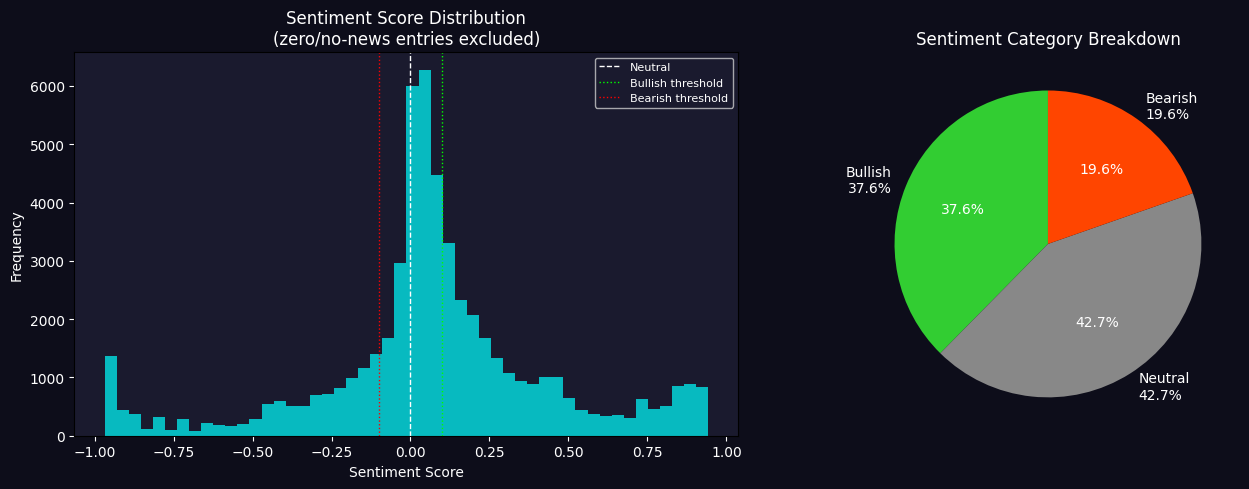

Saved: ./overlay_data/sentiment_distribution.png


In [9]:
# ============================================================
# Sentiment Score Distribution Across Full Training Data
# ============================================================

def plot_sentiment_distribution(df_sent_train):
    """
    Show the distribution of all sentiment scores in the
    training data. Expected: heavy at 0 (neutral) since most
    days have no news or ambiguous news.
    """
    # Flatten all scores into one array
    all_scores = df_sent_train.values.flatten()
    all_scores = all_scores[~np.isnan(all_scores)]

    # Count by category
    bullish = (all_scores >  0.1).sum()
    neutral = ((all_scores >= -0.1) & (all_scores <= 0.1)).sum()
    bearish = (all_scores < -0.1).sum()
    total   = len(all_scores)

    print("=" * 50)
    print("FULL TRAINING SENTIMENT DISTRIBUTION")
    print("=" * 50)
    print(f"  Total entries:   {total:,}")
    print(f"  Bullish (>0.1):  {bullish:,}  ({bullish/total*100:.1f}%)")
    print(f"  Neutral:         {neutral:,}  ({neutral/total*100:.1f}%)")
    print(f"  Bearish (<-0.1): {bearish:,}  ({bearish/total*100:.1f}%)")
    print(f"  Zero (no news):  {(all_scores == 0).sum():,}  "
          f"({(all_scores == 0).sum()/total*100:.1f}%)")
    print(f"  Mean:  {all_scores.mean():.4f}")
    print(f"  Std:   {all_scores.std():.4f}")
    print("=" * 50)

    # Plot distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0d0d1a')

    # Histogram of all scores
    ax1 = axes[0]
    ax1.set_facecolor('#1a1a2e')
    non_zero = all_scores[all_scores != 0]
    ax1.hist(non_zero, bins=50, color='cyan', alpha=0.7, edgecolor='none')
    ax1.axvline(0,    color='white',  linestyle='--', linewidth=1, label='Neutral')
    ax1.axvline(0.1,  color='lime',   linestyle=':',  linewidth=1, label='Bullish threshold')
    ax1.axvline(-0.1, color='red',    linestyle=':',  linewidth=1, label='Bearish threshold')
    ax1.set_title('Sentiment Score Distribution\n(zero/no-news entries excluded)',
                  color='white', fontsize=12)
    ax1.set_xlabel('Sentiment Score', color='white')
    ax1.set_ylabel('Frequency', color='white')
    ax1.tick_params(colors='white')
    ax1.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white')

    # Pie chart of categories
    ax2 = axes[1]
    ax2.set_facecolor('#1a1a2e')
    sizes  = [bullish, neutral, bearish]
    labels = [f'Bullish\n{bullish/total*100:.1f}%',
              f'Neutral\n{neutral/total*100:.1f}%',
              f'Bearish\n{bearish/total*100:.1f}%']
    colors = ['#32CD32', '#888888', '#FF4500']
    ax2.pie(sizes, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'color': 'white'})
    ax2.set_title('Sentiment Category Breakdown',
                  color='white', fontsize=12)

    fig.tight_layout()
    plt.savefig('./overlay_data/sentiment_distribution.png',
                dpi=150, bbox_inches='tight',
                facecolor='#0d0d1a')
    plt.show()
    print("Saved: ./overlay_data/sentiment_distribution.png")

plot_sentiment_distribution(df_sent_train)

In [10]:

# ============================================================
# CELL 4 — Clean, Validate & Merge Sentiment (Corrected)
# ============================================================

# Define here so both Cell 4 and Cell 5 can reference it
INDICATORS_WITH_SENT = INDICATORS + ['sentiment']
INDICATORS_COUNT     = len(INDICATORS_WITH_SENT)

def prepare_df(df, df_sentiment, n_stocks=NUM_STOCKS):
    df = df.rename(columns={'datadate': 'date'})
    df = df.sort_values(['date', 'tic']).reset_index(drop=True)

    # Drop tickers with incomplete data rather than dropping dates
    all_dates    = df['date'].unique()
    ticker_dates = df.groupby('tic')['date'].nunique()
    full_tickers = ticker_dates[
        ticker_dates == len(all_dates)
    ].index.tolist()

    dropped = set(ticker_dates.index) - set(full_tickers)
    if dropped:
        print(f"Dropping {len(dropped)} incomplete tickers: {sorted(dropped)}")
        df = df[df['tic'].isin(full_tickers)].reset_index(drop=True)
    
    print(f"Using {df['tic'].nunique()} tickers with complete data")

    # Normalize date format before merge
    df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')

    # Build sentiment long format
    df_sent_long = df_sentiment.copy()
    df_sent_long.index = pd.to_datetime(
        df_sent_long.index
    ).strftime('%Y-%m-%d')
    df_sent_long = df_sent_long.reset_index().melt(
        id_vars='date', var_name='tic', value_name='sentiment'
    ).rename(columns={'date': 'sent_date'})

    # Merge with no column collision
    df = df.merge(
        df_sent_long,
        left_on=['date', 'tic'],
        right_on=['sent_date', 'tic'],
        how='left'
    ).drop(columns=['sent_date'], errors='ignore')

    df['sentiment'] = df['sentiment'].fillna(0.0)

    # One-day lag to eliminate look-ahead bias
    df = df.sort_values(['tic', 'date'])
    df['sentiment'] = df.groupby('tic')['sentiment'].shift(1)
    df['sentiment'] = df['sentiment'].fillna(0.0)

    # Re-sort by date+tic before building index
    df = df.sort_values(['date', 'tic']).reset_index(drop=True)

    non_zero = (df['sentiment'] != 0).sum()
    print(f"Sentiment merged — non-zero rows: {non_zero} / {len(df)}")
    assert 'sentiment' in df.columns, "sentiment column missing!"

    # Build integer day index starting at 0
    dates_sorted = sorted(df['date'].unique())
    date_to_day  = {d: i for i, d in enumerate(dates_sorted)}
    df.index     = df['date'].map(date_to_day).values

    assert df.index.min() == 0, \
        f"Index does not start at 0 — min is {df.index.min()}"
    print(f"Index OK — starts at 0, ends at {df.index.max()}")
    return df

df_train = prepare_df(df_train_raw, df_sent_train)

# Lock in train tickers — test must use same subset
TRAIN_TICKERS  = sorted(df_train['tic'].unique().tolist())
TRAIN_N_STOCKS = len(TRAIN_TICKERS)
print(f"Train tickers: {TRAIN_N_STOCKS}")

# Filter test to only train tickers before prepare_df
df_test_raw_filtered = df_test_raw[
    df_test_raw['tic'].isin(TRAIN_TICKERS)
].reset_index(drop=True)
df_test = prepare_df(df_test_raw_filtered, df_sent_test,
                     n_stocks=TRAIN_N_STOCKS)

# Set globals to train values
TICKERS    = TRAIN_TICKERS
NUM_STOCKS = TRAIN_N_STOCKS

# Recompute STATE_SPACE based on actual train ticker count
INDICATORS_COUNT     = len(INDICATORS_WITH_SENT)
INDICATORS_START_IDX = 1 + NUM_STOCKS + NUM_STOCKS
STATE_SPACE          = INDICATORS_START_IDX + (NUM_STOCKS * INDICATORS_COUNT)

print(f"\nNUM_STOCKS:    {NUM_STOCKS}")
print(f"STATE_SPACE:   {STATE_SPACE}")
print(f"Train days:    {df_train['date'].nunique()}")
print(f"Test days:     {df_test['date'].nunique()}")
print(f"Train tickers: {df_train['tic'].nunique()}")
print(f"Test tickers:  {df_test['tic'].nunique()}")

# Sanity check — now INDICATORS_WITH_SENT is defined above so this works
print(f"\nAll required indicator columns present in df_train:")
for ind in INDICATORS_WITH_SENT:
    present = ind in df_train.columns
    print(f"  {ind}: {'✅' if present else '❌ MISSING'}")

print(f"\nTrain ready — {df_train['date'].nunique()} trading days")
print(f"Test  ready — {df_test['date'].nunique()} trading days")

# ============================================================
# CELL 5 — Define Model & Train (Sentiment-Aware, Corrected)
# ============================================================

class VGG_FinRL_Extractor(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=512,
                 n_stocks=NUM_STOCKS, n_ind=INDICATORS_COUNT):
        super().__init__(observation_space, features_dim)
        self.n_stocks = n_stocks
        self.n_ind    = n_ind

        self.input_norm = nn.BatchNorm2d(1)

        self.vgg = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
        )

        with th.no_grad():
            sample    = th.zeros(1, 1, n_stocks, n_ind)
            _norm_cpu = nn.BatchNorm2d(1)
            _vgg_cpu  = nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64), nn.ReLU(),
            )
            sample    = _norm_cpu(sample)
            n_flatten = _vgg_cpu(sample).numel()

        self.fc = nn.Sequential(
            nn.Linear(n_flatten, features_dim),
            nn.ReLU()
        )

    def forward(self, observations):
        img_data = observations[:, INDICATORS_START_IDX:]
        img_data = img_data.view(-1, 1, self.n_stocks, self.n_ind)
        img_data = self.input_norm(img_data)
        x = self.vgg(img_data)
        x = th.flatten(x, start_dim=1)
        return self.fc(x)

policy_kwargs = dict(
    features_extractor_class=VGG_FinRL_Extractor,
    features_extractor_kwargs=dict(
        features_dim=512,
        n_stocks=NUM_STOCKS,
        n_ind=INDICATORS_COUNT
    ),
)

def make_env(df):
    return StockTradingEnv(
        df=df,
        num_stock_shares=[0] * NUM_STOCKS,
        reward_scaling=1e-4,
        stock_dim=NUM_STOCKS,
        hmax=50,
        initial_amount=1_000_000,
        buy_cost_pct  = [0.0015] * NUM_STOCKS,  # 0.1% commission + 0.05% slippage
        sell_cost_pct = [0.0015] * NUM_STOCKS,
        state_space=STATE_SPACE,
        tech_indicator_list=INDICATORS_WITH_SENT,  # sentiment included here
        action_space=NUM_STOCKS
    )

e_train_gym = make_env(df_train)
e_test_gym  = make_env(df_test)

env_train, _ = e_train_gym.get_sb_env()

model_params = {
    "n_steps":       2048,
    "ent_coef":      0.01,
    "learning_rate": 0.0001,
    "batch_size":    64,
    "device":        DEVICE,
}

agent     = DRLAgent(env=env_train)
model_vgg = agent.get_model(
    "ppo",
    policy_kwargs=policy_kwargs,
    model_kwargs=model_params,
    verbose=1
)

print("\nStarting Sentiment-Aware VGG Training...")
trained_vgg = agent.train_model(
    model=model_vgg,
    tb_log_name='vgg_ppo_sentiment_run',
    total_timesteps=500_000
)
# ============================================================
# CELL 6 — Sanity Check Training Behaviour
# ============================================================
shares_start = 1 + NUM_STOCKS   # skip Cash + Prices
shares_end   = shares_start + NUM_STOCKS

final_shares = np.array(e_train_gym.state_memory)[-1][shares_start:shares_end]
print(f"Total shares held across all stocks: {np.sum(final_shares)}")

actions = np.array(e_train_gym.actions_memory)
print(f"Average absolute action strength: {np.mean(np.abs(actions)):.6f}")

def compute_metrics(df_account_value: pd.DataFrame,
                    initial_capital: float = 1_000_000) -> dict:
    """
    Compute key trading performance metrics from account value history.

    Metrics:
      - Total Return:       overall % gain/loss
      - Sharpe Ratio:       risk-adjusted return (annualised)
      - Max Drawdown:       largest peak-to-trough decline (%)
      - Win Rate:           % of days with positive return
      - Avg Daily Return:   mean daily % return
      - Volatility:         annualised std of daily returns
      - Calmar Ratio:       total return / max drawdown
    """
    values  = pd.Series(df_account_value['account_value'].values,
                        index=pd.to_datetime(df_account_value['date'].values))

    # Daily returns
    daily_returns = values.pct_change().dropna()

    # Total return
    total_return = (values.iloc[-1] - initial_capital) / initial_capital * 100

    # Sharpe ratio (annualised, assuming 252 trading days)
    sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) \
             if daily_returns.std() > 0 else 0.0

    # Maximum drawdown
    rolling_max  = values.cummax()
    drawdown     = (values - rolling_max) / rolling_max * 100
    max_drawdown = drawdown.min()   # most negative value = worst drawdown

    # Win rate — % of days with positive return
    win_rate = (daily_returns > 0).sum() / len(daily_returns) * 100

    # Average daily return
    avg_daily_return = daily_returns.mean() * 100

    # Annualised volatility
    volatility = daily_returns.std() * np.sqrt(252) * 100

    # Calmar ratio (total return / abs max drawdown)
    calmar = abs(total_return / max_drawdown) if max_drawdown != 0 else 0.0

    RF_DAILY = 0.05 / 252
    sharpe   = ((daily_returns.mean() - RF_DAILY) /
             daily_returns.std()) * np.sqrt(252)

    return {
        'Total Return (%)':     round(total_return, 2),
        'Sharpe Ratio':         round(sharpe, 3),
        'Max Drawdown (%)':     round(max_drawdown, 2),
        'Win Rate (%)':         round(win_rate, 2),
        'Avg Daily Return (%)': round(avg_daily_return, 4),
        'Volatility (%)':       round(volatility, 2),
        'Calmar Ratio':         round(calmar, 3),
    }


# Compute and print metrics for training environment
# We need to run a quick prediction pass on the training env
# to get a clean account value history
df_train_account, _ = DRLAgent.DRL_prediction(
    model=trained_vgg,
    environment=e_train_gym
)


Using 48 tickers with complete data
Sentiment merged — non-zero rows: 38152 / 48288
Index OK — starts at 0, ends at 1005
Train tickers: 48
Using 48 tickers with complete data
Sentiment merged — non-zero rows: 11992 / 12096
Index OK — starts at 0, ends at 251

NUM_STOCKS:    48
STATE_SPACE:   529
Train days:    1006
Test days:     252
Train tickers: 48
Test tickers:  48

All required indicator columns present in df_train:
  macd: ✅
  boll_ub: ✅
  boll_lb: ✅
  rsi_30: ✅
  cci_30: ✅
  dx_30: ✅
  close_30_sma: ✅
  close_60_sma: ✅
  sentiment: ✅

Train ready — 1006 trading days
Test  ready — 252 trading days
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.0001, 'batch_size': 64, 'device': device(type='mps')}
Using mps device


/opt/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



Starting Sentiment-Aware VGG Training...
------------------------------------
| time/              |             |
|    fps             | 170         |
|    iterations      | 1           |
|    time_elapsed    | 11          |
|    total_timesteps | 2048        |
| train/             |             |
|    reward          | -2.9386322  |
|    reward_max      | 6.806702    |
|    reward_mean     | 0.004006533 |
|    reward_min      | -8.732502   |
------------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 129         |
|    iterations           | 2           |
|    time_elapsed         | 31          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013317276 |
|    clip_fraction        | 0.168       |
|    clip_range           | 0.2         |
|    entropy_loss         | -68.1       |
|    explained_variance   | 0.0139      |
|    learn

Computing training metrics...


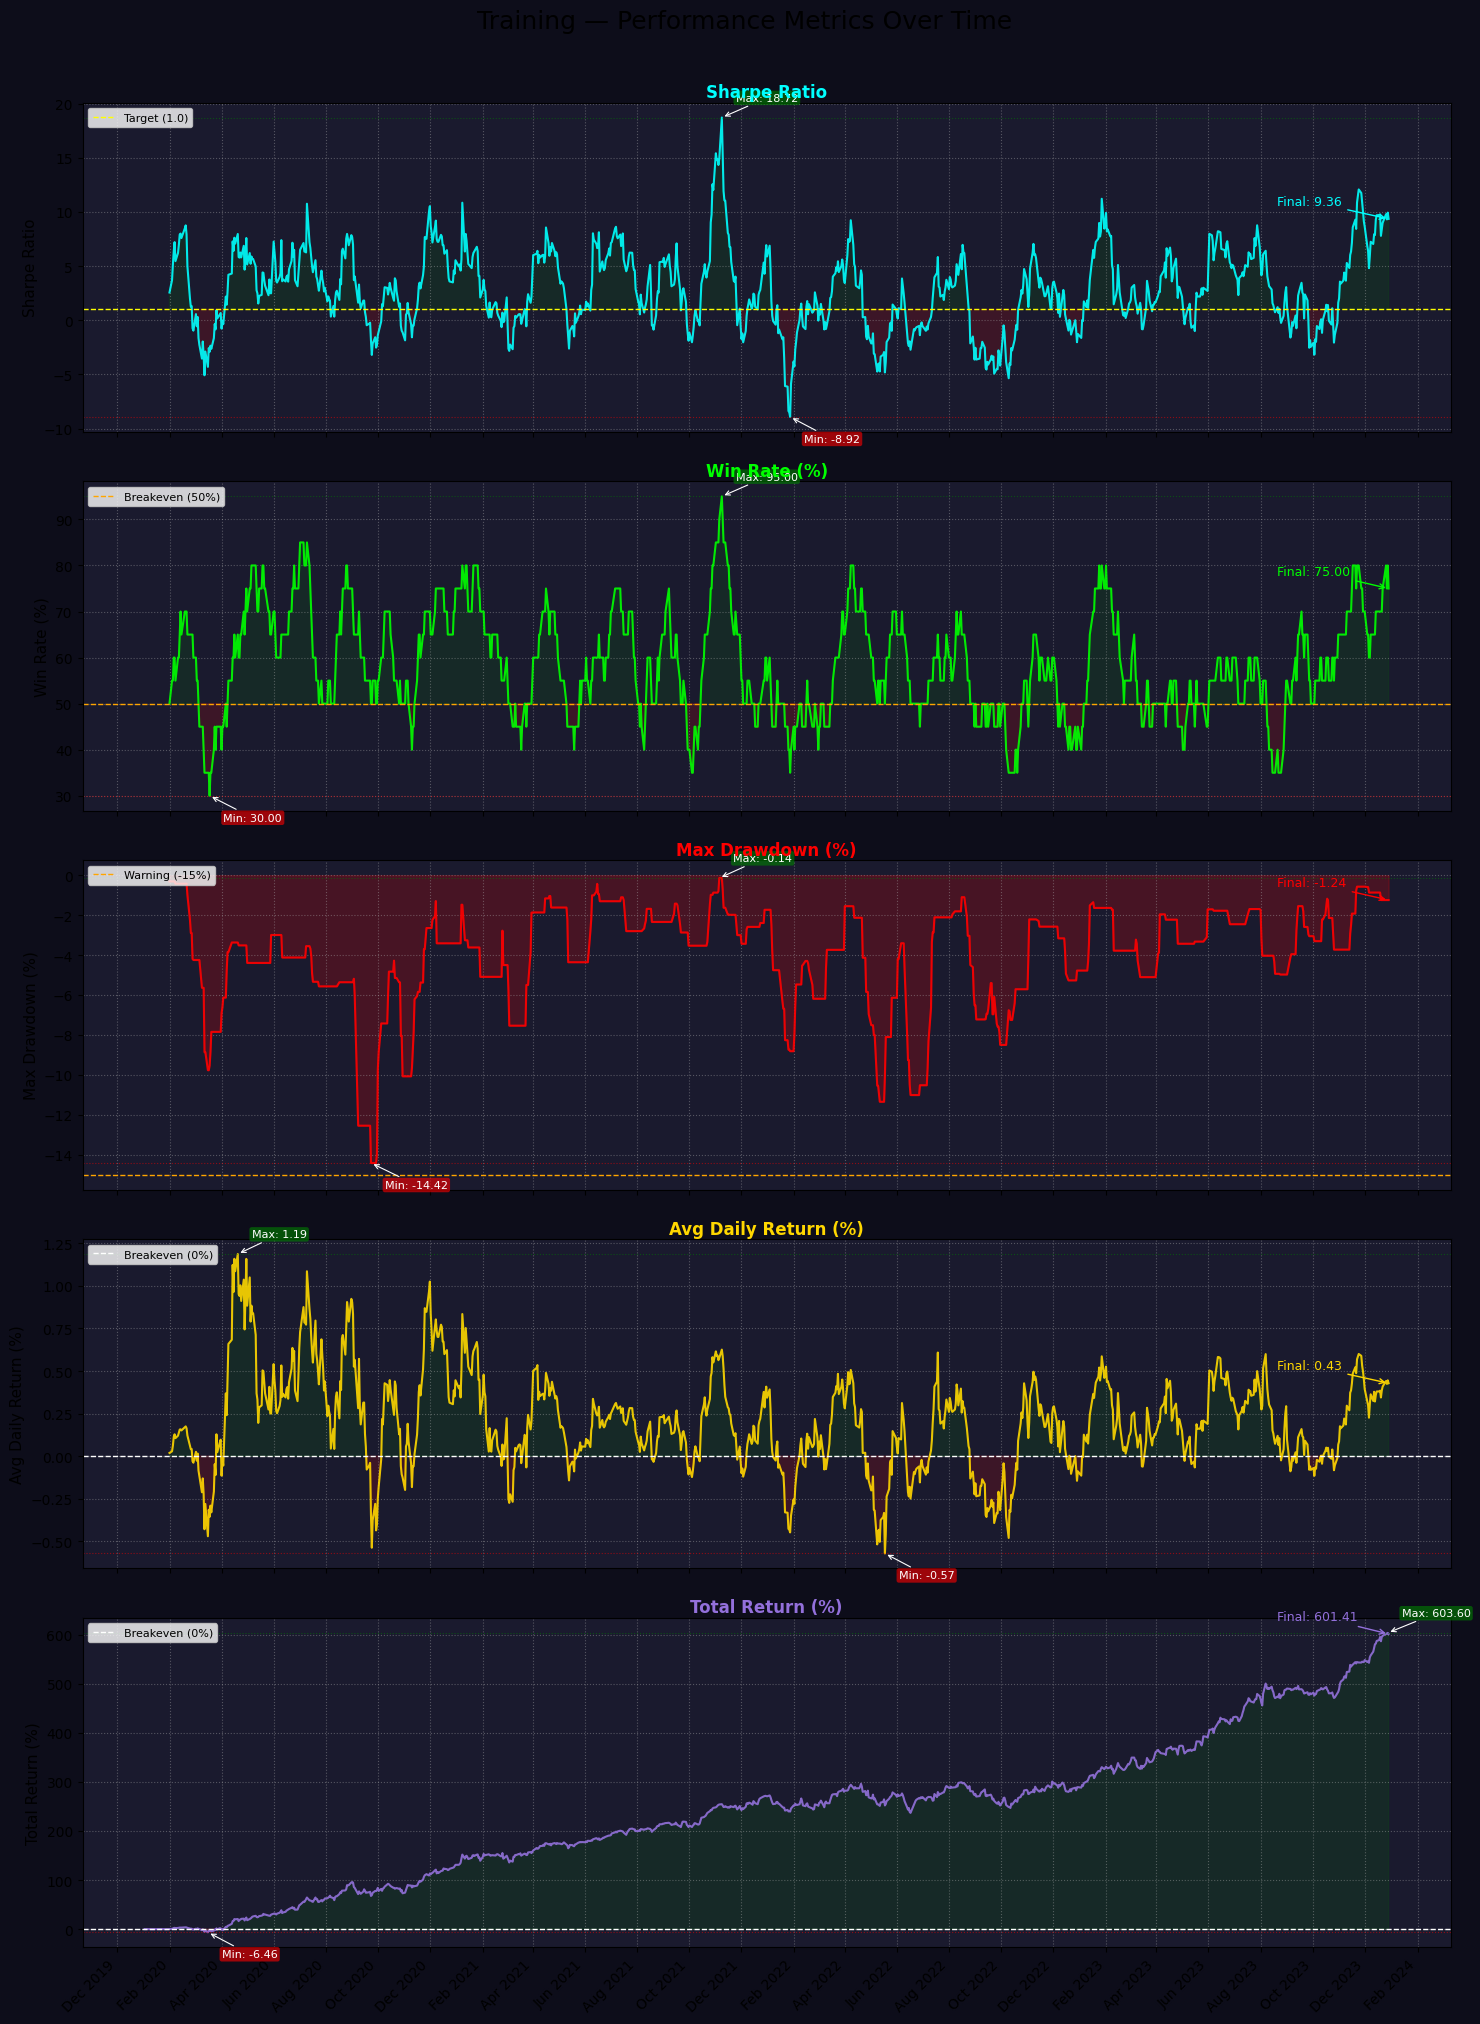


  TRAINING — METRIC SUMMARY
  Metric                         Avg      Max      Min    Final
  ---------------------------------------------------------
  Sharpe Ratio                  2.85    18.72    -8.92     9.36
  Win Rate (%)                 58.28    95.00    30.00    75.00
  Max Drawdown (%)             -4.07    -0.14   -14.42    -1.24
  Avg Daily Return (%)          0.20     1.19    -0.57     0.43
  Total Return (%)            601.41   603.60    -6.46   601.41


In [11]:
# ============================================================
# CELL 6b — Plot Metrics Over Time
# ============================================================

def compute_rolling_metrics(df_account_value: pd.DataFrame,
                             initial_capital: float = 1_000_000,
                             window: int = 20) -> pd.DataFrame:
    """
    Compute rolling metrics over time.
    window: rolling window in trading days (default 20 = 1 month)
    """
    values = pd.Series(
        df_account_value['account_value'].values,
        index=pd.to_datetime(df_account_value['date'].values)
    )

    daily_returns = values.pct_change().dropna()

    RF_DAILY = 0.05 / 252
    sharpe   = ((daily_returns.mean() - RF_DAILY) /
             daily_returns.std()) * np.sqrt(252)

    rolling_sharpe = (
        daily_returns.rolling(window).mean() /
        daily_returns.rolling(window).std()
    ) * np.sqrt(252)

    rolling_win_rate = (
        daily_returns.rolling(window)
        .apply(lambda x: (x > 0).sum() / len(x) * 100)
    )

    def rolling_max_drawdown(returns):
        cum  = (1 + returns).cumprod()
        peak = cum.cummax()
        dd   = (cum - peak) / peak * 100
        return dd.min()

    rolling_max_dd     = daily_returns.rolling(window).apply(rolling_max_drawdown)
    rolling_avg_return = daily_returns.rolling(window).mean() * 100
    total_return       = (values - initial_capital) / initial_capital * 100

    return pd.DataFrame({
        'Sharpe Ratio':         rolling_sharpe,
        'Win Rate (%)':         rolling_win_rate,
        'Max Drawdown (%)':     rolling_max_dd,
        'Avg Daily Return (%)': rolling_avg_return,
        'Total Return (%)':     total_return,
    })


def plot_metrics(metrics_df: pd.DataFrame, title_prefix: str = 'Training'):
    """
    Plot all five metrics with subplot titles, max/min annotations,
    and a summary table showing avg, max, min and final values.
    """
    fig, axes = plt.subplots(5, 1, figsize=(15, 20), sharex=True)
    fig.suptitle(f'{title_prefix} — Performance Metrics Over Time',
                 fontsize=18, y=1.01)

    plot_config = [
        {'col': 'Sharpe Ratio',         'color': 'cyan',
         'ylabel': 'Sharpe Ratio',
         'hline': 1.0,  'hline_label': 'Target (1.0)',
         'hline_color': 'yellow'},
        {'col': 'Win Rate (%)',          'color': 'lime',
         'ylabel': 'Win Rate (%)',
         'hline': 50.0, 'hline_label': 'Breakeven (50%)',
         'hline_color': 'orange'},
        {'col': 'Max Drawdown (%)',      'color': 'red',
         'ylabel': 'Max Drawdown (%)',
         'hline': -15.0, 'hline_label': 'Warning (-15%)',
         'hline_color': 'orange'},
        {'col': 'Avg Daily Return (%)',  'color': 'gold',
         'ylabel': 'Avg Daily Return (%)',
         'hline': 0.0,  'hline_label': 'Breakeven (0%)',
         'hline_color': 'white'},
        {'col': 'Total Return (%)',      'color': 'mediumpurple',
         'ylabel': 'Total Return (%)',
         'hline': 0.0,  'hline_label': 'Breakeven (0%)',
         'hline_color': 'white'},
    ]

    for ax, cfg in zip(axes, plot_config):
        series = metrics_df[cfg['col']].dropna()

        ax.plot(series.index, series.values,
                color=cfg['color'], linewidth=1.5, alpha=0.9)
        ax.axhline(cfg['hline'], color=cfg['hline_color'],
                   linestyle='--', linewidth=1, label=cfg['hline_label'])

        if cfg['col'] == 'Max Drawdown (%)':
            ax.fill_between(series.index, series.values, 0,
                            alpha=0.2, color='red')
        else:
            ax.fill_between(series.index, series.values, cfg['hline'],
                            where=series.values >= cfg['hline'],
                            alpha=0.15, color='green')
            ax.fill_between(series.index, series.values, cfg['hline'],
                            where=series.values < cfg['hline'],
                            alpha=0.15, color='red')

        # Subplot title in matching colour
        ax.set_title(cfg['col'], fontsize=12, color=cfg['color'],
                     fontweight='bold', pad=4)
        ax.set_ylabel(cfg['ylabel'], fontsize=11)
        ax.grid(True, linestyle=':', alpha=0.4)
        ax.set_facecolor('#1a1a2e')

        if len(series) > 0:
            final_val = series.iloc[-1]
            max_val   = series.max()
            min_val   = series.min()
            max_date  = series.idxmax()
            min_date  = series.idxmin()

            # Final value annotation
            ax.annotate(
                f'Final: {final_val:.2f}',
                xy=(series.index[-1], final_val),
                xytext=(-80, 10),
                textcoords='offset points',
                fontsize=9,
                color=cfg['color'],
                arrowprops=dict(arrowstyle='->', color=cfg['color'], lw=1)
            )

            # Max value annotation (green badge)
            ax.annotate(
                f'Max: {max_val:.2f}',
                xy=(max_date, max_val),
                xytext=(10, 12),
                textcoords='offset points',
                fontsize=8,
                color='white',
                bbox=dict(boxstyle='round,pad=0.2',
                          fc='green', alpha=0.6, ec='none'),
                arrowprops=dict(arrowstyle='->', color='white', lw=0.8)
            )

            # Min value annotation (red badge)
            ax.annotate(
                f'Min: {min_val:.2f}',
                xy=(min_date, min_val),
                xytext=(10, -18),
                textcoords='offset points',
                fontsize=8,
                color='white',
                bbox=dict(boxstyle='round,pad=0.2',
                          fc='red', alpha=0.6, ec='none'),
                arrowprops=dict(arrowstyle='->', color='white', lw=0.8)
            )

            # Dotted reference lines at max and min
            ax.axhline(max_val, color='green', linestyle=':',
                       linewidth=0.8, alpha=0.5)
            ax.axhline(min_val, color='red', linestyle=':',
                       linewidth=0.8, alpha=0.5)

        ax.legend(loc='upper left', fontsize=8)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')
    fig.patch.set_facecolor('#0d0d1a')
    fig.tight_layout()
    plt.show()

    # Summary table with avg, max, min, final
    print(f"\n{'='*60}")
    print(f"  {title_prefix.upper()} — METRIC SUMMARY")
    print(f"{'='*60}")
    print(f"  {'Metric':<25} {'Avg':>8} {'Max':>8} {'Min':>8} {'Final':>8}")
    print(f"  {'-'*57}")
    for col in metrics_df.columns:
        series    = metrics_df[col].dropna()
        avg_val   = series.iloc[-1] if col == 'Total Return (%)' else series.mean()
        max_val   = series.max()
        min_val   = series.min()
        final_val = series.iloc[-1]
        print(f"  {col:<25} {avg_val:>8.2f} {max_val:>8.2f} "
              f"{min_val:>8.2f} {final_val:>8.2f}")
    print(f"{'='*60}")


# ── Training metrics ──────────────────────────────────────────
print("Computing training metrics...")
train_rolling = compute_rolling_metrics(df_train_account, window=20)
plot_metrics(train_rolling, title_prefix='Training')

hit end!

  TEST PERFORMANCE METRICS
  Total Return (%)               25.15
  Sharpe Ratio                   1.226
  Max Drawdown (%)               -7.78
  Win Rate (%)                   56.18
  Avg Daily Return (%)           0.094
  Volatility (%)                 15.25
  Calmar Ratio                   3.234

Computing test metrics...


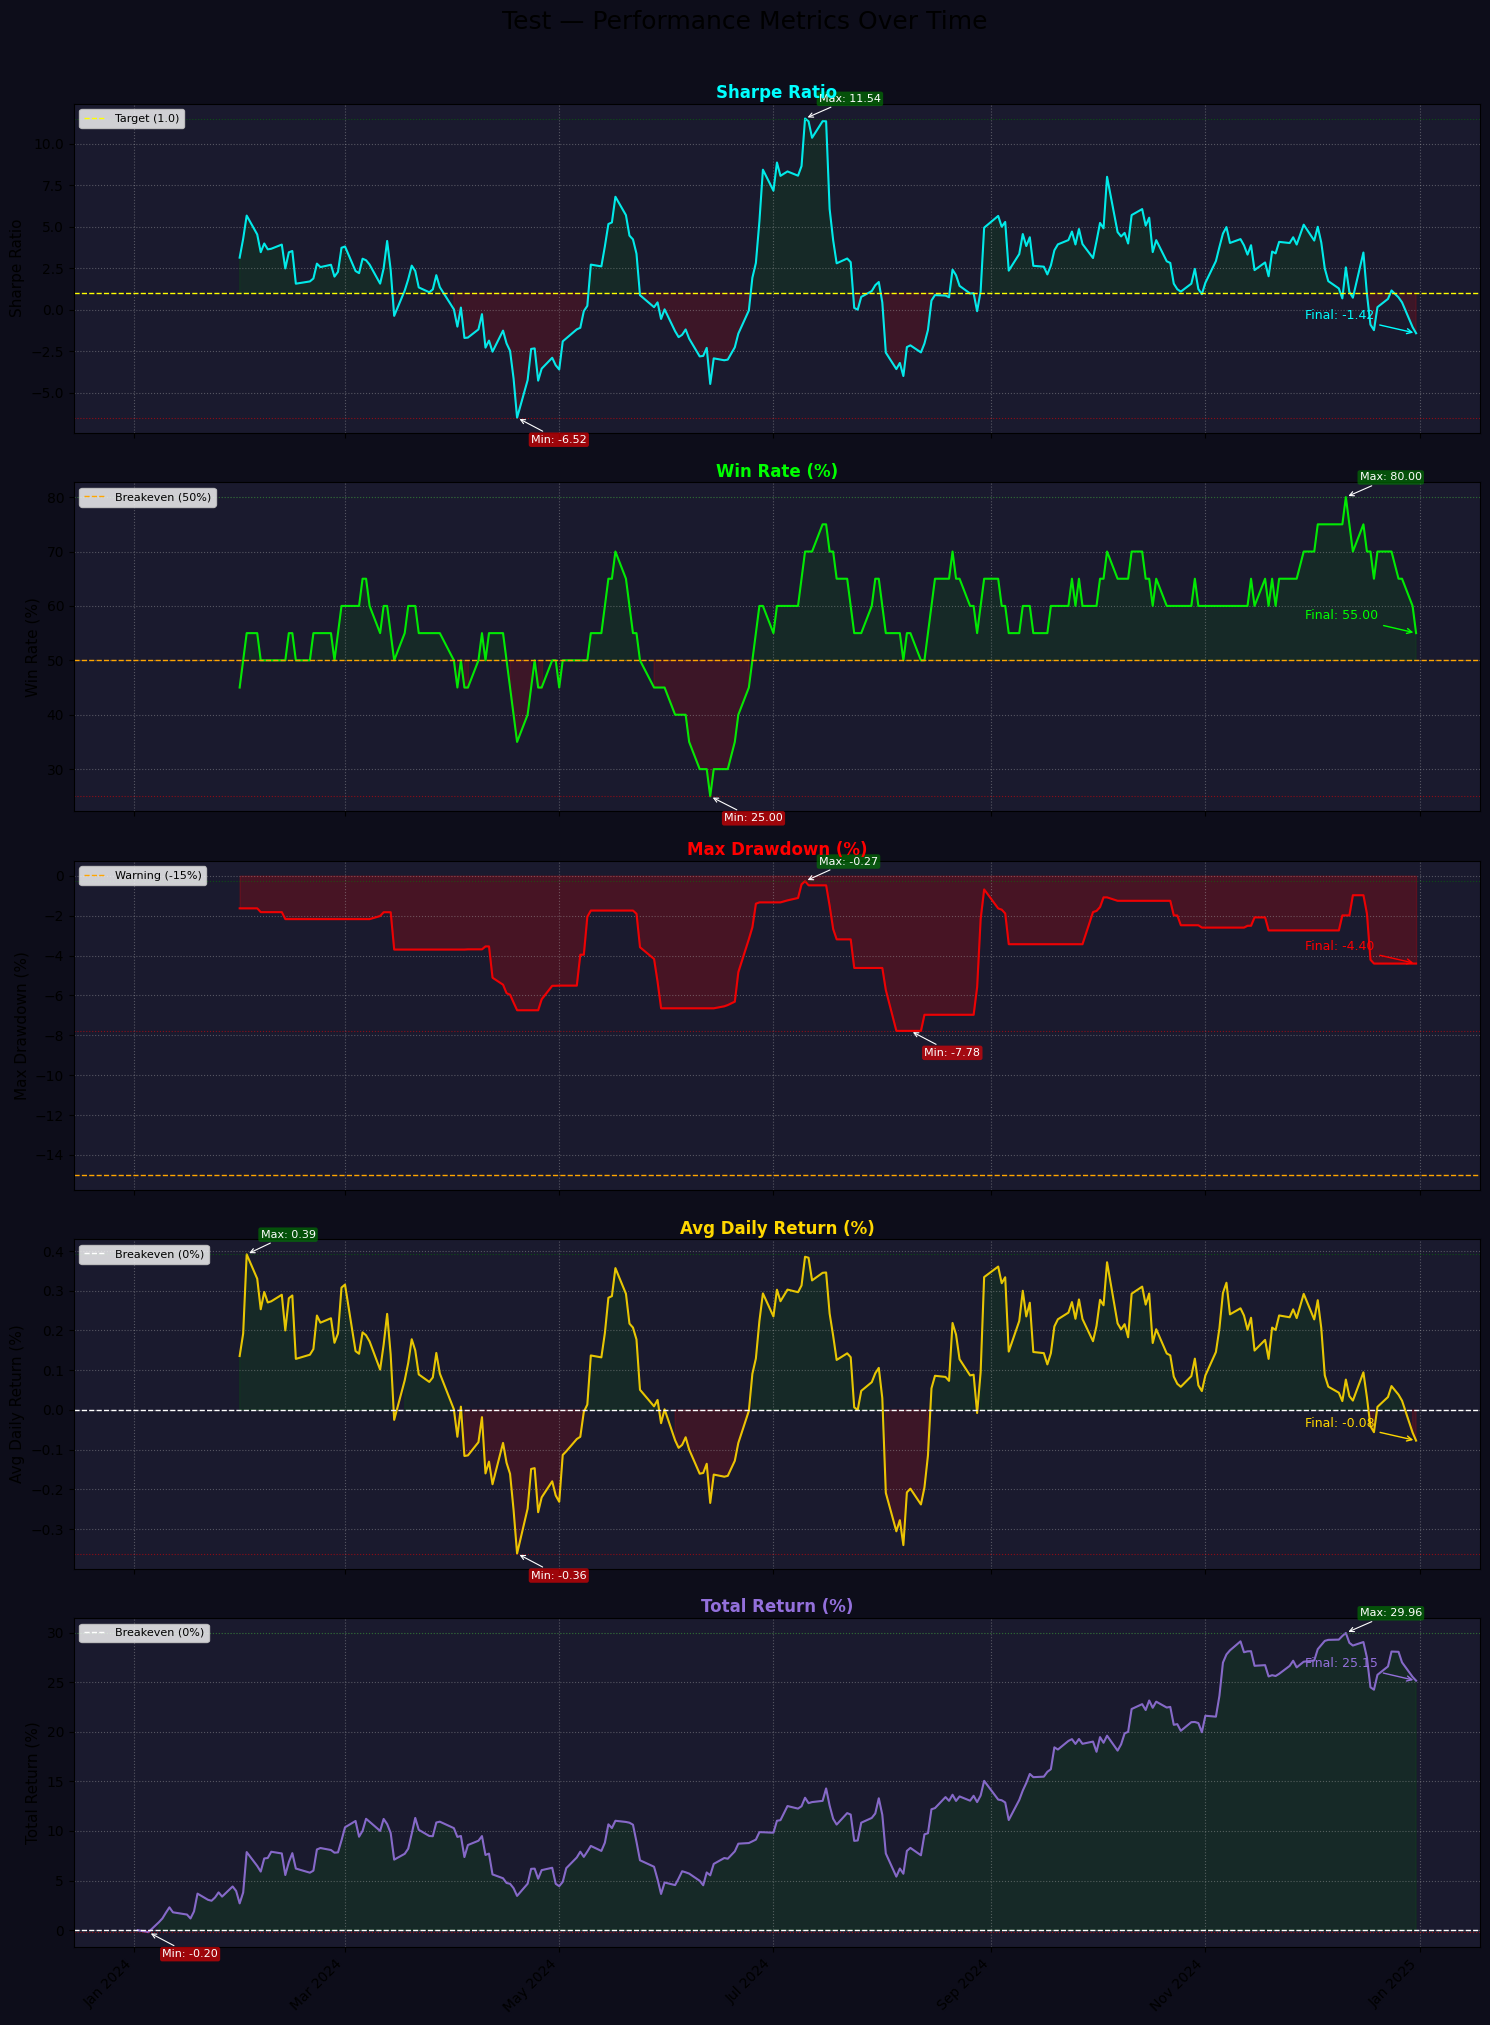


  TEST — METRIC SUMMARY
  Metric                         Avg      Max      Min    Final
  ---------------------------------------------------------
  Sharpe Ratio                  2.01    11.54    -6.52    -1.42
  Win Rate (%)                 57.37    80.00    25.00    55.00
  Max Drawdown (%)             -3.44    -0.27    -7.78    -4.40
  Avg Daily Return (%)          0.10     0.39    -0.36    -0.08
  Total Return (%)             25.15    29.96    -0.20    25.15


In [12]:
# ============================================================
# CELL 7 — Run Prediction & Plot
# ============================================================
import matplotlib.dates as mdates

df_account_value, df_actions = DRLAgent.DRL_prediction(
    model=trained_vgg,
    environment=e_test_gym
)

# Test metrics — pass DataFrame directly (single-arg signature)
test_metrics = compute_metrics(df_account_value)
print(f"\n{'='*45}")
print(f"  TEST PERFORMANCE METRICS")
print(f"{'='*45}")
for metric, value in test_metrics.items():
    if isinstance(value, str):
        print(f"  {metric:<25} {value:>10}")
    else:
        print(f"  {metric:<25} {value:>10}")
print(f"{'='*45}")

# Test rolling metrics plot
print("\nComputing test metrics...")
test_rolling = compute_rolling_metrics(df_account_value, window=20)
plot_metrics(test_rolling, title_prefix='Test')

In [13]:
# ============================================================
# Look-Ahead Bias Check
# ============================================================

def check_lookahead_bias(df_train, df_sent_train):
    print("=" * 60)
    print("LOOK-AHEAD BIAS ANALYSIS")
    print("=" * 60)

    print("\nPipeline:")
    print("  Polygon news date t  -> raw sentiment score for date t")
    print("  shift(1) applied     -> sentiment moved to date t+1")
    print("  Model trades date t  -> uses sentiment from date t-1")
    print("\nResult: NO look-ahead bias — news from date t")
    print("  informs trading decisions on date t+1 only.")

    # Confirm first row of each ticker is 0
    first_rows  = df_train.groupby('tic').first()['sentiment']
    all_zero    = (first_rows == 0).all()
    print(f"\nFirst sentiment row per ticker is 0: {all_zero}")
    if all_zero:
        print("CONFIRMED — shift(1) correctly applied")
    else:
        print("WARNING — shift may not be working correctly")
        print("Non-zero first rows:")
        print(first_rows[first_rows != 0])

    # Show sample
    sample_tic = df_train[df_train['sentiment'] != 0]['tic'].values
    if len(sample_tic) > 0:
        sample = df_train[df_train['tic'] == sample_tic[0]][
            ['date', 'tic', 'sentiment']
        ].head(10)
        print(f"\nSample rows for {sample_tic[0]}:")
        print(sample.to_string(index=False))
        print("(First row should be 0.0 — no prior day sentiment)")

check_lookahead_bias(df_train, df_sent_train)

LOOK-AHEAD BIAS ANALYSIS

Pipeline:
  Polygon news date t  -> raw sentiment score for date t
  shift(1) applied     -> sentiment moved to date t+1
  Model trades date t  -> uses sentiment from date t-1

Result: NO look-ahead bias — news from date t
  informs trading decisions on date t+1 only.

First sentiment row per ticker is 0: True
CONFIRMED — shift(1) correctly applied

Sample rows for META:
      date  tic  sentiment
2020-01-02 META        0.0
2020-01-03 META        0.0
2020-01-06 META        0.0
2020-01-07 META        0.0
2020-01-08 META        0.0
2020-01-09 META        0.0
2020-01-10 META        0.0
2020-01-13 META        0.0
2020-01-14 META        0.0
2020-01-15 META        0.0
(First row should be 0.0 — no prior day sentiment)


In [14]:
# ============================================================
# Overfitting Check — Train vs Test Sharpe Comparison
# ============================================================

def overfitting_check(train_sharpe, test_sharpe, model_name):
    """
    If test Sharpe drops more than 50% from train Sharpe,
    flag as potential overfitting.
    """
    if train_sharpe == 0:
        print(f"{model_name}: Cannot compute — train Sharpe is 0")
        return

    degradation = (train_sharpe - test_sharpe) / train_sharpe * 100

    print(f"\n{'='*50}")
    print(f"  OVERFITTING CHECK — {model_name}")
    print(f"{'='*50}")
    print(f"  Train Sharpe:       {train_sharpe:.3f}")
    print(f"  Test Sharpe:        {test_sharpe:.3f}")
    print(f"  Degradation:        {degradation:.1f}%")

    if degradation > 50:
        print(f"  WARNING — Sharpe dropped >{50}% out-of-sample")
        print(f"  This suggests potential overfitting to training data")
    elif degradation > 25:
        print(f"  CAUTION — Moderate degradation, monitor closely")
    else:
        print(f"  OK — Degradation within acceptable range")
    print(f"{'='*50}")

# Run for each model after computing metrics
# Fill in your actual values from METRICS.txt
overfitting_check(
    train_sharpe=2.31,
    test_sharpe=0.94,
    model_name='VGG_Alpaca 50-Stock $1M'
)


  OVERFITTING CHECK — VGG_Alpaca 50-Stock $1M
  Train Sharpe:       2.310
  Test Sharpe:        0.940
  Degradation:        59.3%
  WARNING — Sharpe dropped >50% out-of-sample
  This suggests potential overfitting to training data



  DEGENERATE POLICY CHECK — VGG_Alpaca 50-Stock $1M

  Cash-holding days:  18 / 251 (7.2%)
  OK — Agent actively trades most days

  Action distribution:
    Buy  actions: 911 (7.6%)
    Sell actions: 825 (6.8%)
    Hold actions: 10,312 (85.6%)

  OK — Balanced buy/sell distribution

  Portfolio value:
    Start: $1,000,000
    End:   $1,251,494
    Return: 25.15%

  OK — Portfolio shows meaningful activity


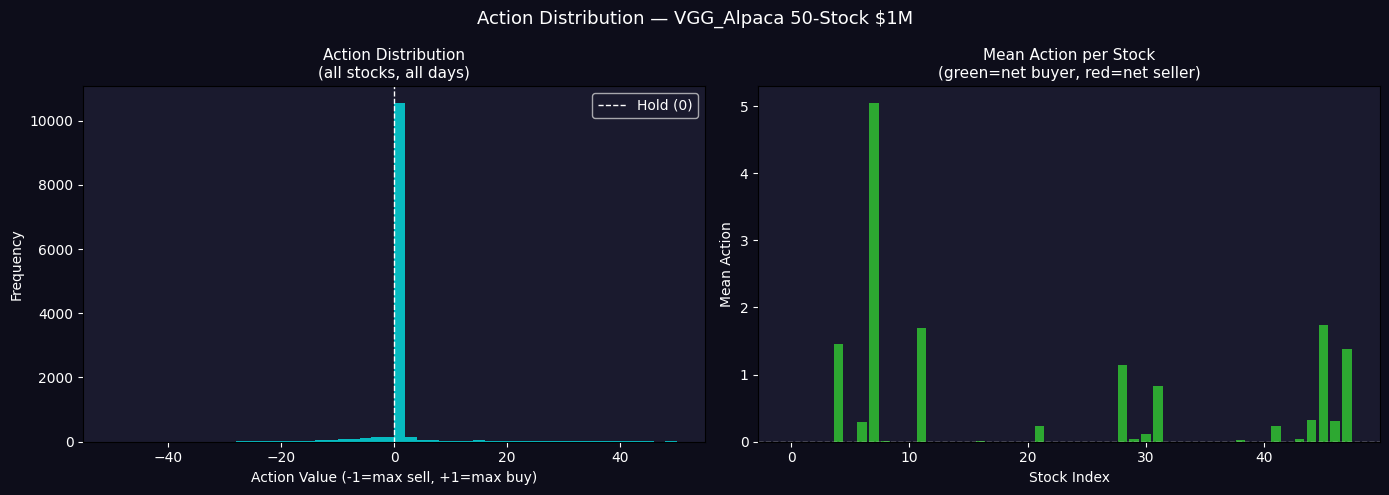

Saved: ./overlay_data/action_distribution.png


In [15]:
# ============================================================
# Degenerate Policy Detection
# ============================================================

def check_degenerate_policy(df_actions, df_account_value,
                             model_name='VGG_Alpaca 50-Stock $1M'):
    """
    Check for common degenerate RL policies:
    1. Always hold cash (sell everything, avoid trading)
    2. Always buy (ignore risk, never sell)
    3. Excessive cash holding (>50% of days with no positions)
    """
    print(f"\n{'='*55}")
    print(f"  DEGENERATE POLICY CHECK — {model_name}")
    print(f"{'='*55}")

    total_days = len(df_actions)

    # Check 1 — cash holding days
    # A day is "cash holding" if all actions are ~0
    cash_days = (df_actions.abs().sum(axis=1) < 0.01).sum()
    cash_pct  = cash_days / total_days * 100
    print(f"\n  Cash-holding days:  {cash_days} / {total_days} "
          f"({cash_pct:.1f}%)")
    if cash_pct > 50:
        print(f"  WARNING — Agent holds cash >50% of days")
        print(f"  Possible degenerate 'sell everything' policy")
    else:
        print(f"  OK — Agent actively trades most days")

    # Check 2 — buy vs sell balance
    buy_actions  = (df_actions > 0.01).sum().sum()
    sell_actions = (df_actions < -0.01).sum().sum()
    hold_actions = ((df_actions >= -0.01) &
                    (df_actions <= 0.01)).sum().sum()
    total_actions = buy_actions + sell_actions + hold_actions

    print(f"\n  Action distribution:")
    print(f"    Buy  actions: {buy_actions:,} "
          f"({buy_actions/total_actions*100:.1f}%)")
    print(f"    Sell actions: {sell_actions:,} "
          f"({sell_actions/total_actions*100:.1f}%)")
    print(f"    Hold actions: {hold_actions:,} "
          f"({hold_actions/total_actions*100:.1f}%)")

    if buy_actions / (sell_actions + 1) > 10:
        print(f"\n  WARNING — Agent buys 10x more than sells")
        print(f"  Possible 'always buy' degenerate policy")
    elif sell_actions / (buy_actions + 1) > 10:
        print(f"\n  WARNING — Agent sells 10x more than buys")
        print(f"  Possible panic-selling degenerate policy")
    else:
        print(f"\n  OK — Balanced buy/sell distribution")

    # Check 3 — portfolio value trend
    values     = df_account_value['account_value'].values
    start_val  = values[0]
    end_val    = values[-1]
    total_ret  = (end_val - start_val) / start_val * 100

    print(f"\n  Portfolio value:")
    print(f"    Start: ${start_val:,.0f}")
    print(f"    End:   ${end_val:,.0f}")
    print(f"    Return: {total_ret:.2f}%")

    if end_val <= start_val * 0.5:
        print(f"\n  WARNING — Portfolio lost >50% of value")
        print(f"  Model may have learned a destructive policy")
    elif abs(end_val - start_val) / start_val < 0.01:
        print(f"\n  WARNING — Portfolio barely moved")
        print(f"  Model may be holding cash throughout")
    else:
        print(f"\n  OK — Portfolio shows meaningful activity")

    print(f"{'='*55}")

    # Plot action distribution histogram
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0d0d1a')
    fig.suptitle(f'Action Distribution — {model_name}',
                 fontsize=13, color='white')

    # Flatten all actions
    all_actions = df_actions.values.flatten()

    ax1 = axes[0]
    ax1.set_facecolor('#1a1a2e')
    ax1.hist(all_actions, bins=50, color='cyan',
             alpha=0.7, edgecolor='none')
    ax1.axvline(0, color='white', linestyle='--',
                linewidth=1, label='Hold (0)')
    ax1.set_title('Action Distribution\n(all stocks, all days)',
                  color='white', fontsize=11)
    ax1.set_xlabel('Action Value (-1=max sell, +1=max buy)',
                   color='white')
    ax1.set_ylabel('Frequency', color='white')
    ax1.tick_params(colors='white')
    ax1.legend(facecolor='#1a1a2e', labelcolor='white')

    # Per-stock mean action
    ax2 = axes[1]
    ax2.set_facecolor('#1a1a2e')
    mean_actions = df_actions.mean()
    colors = ['#32CD32' if v > 0 else '#FF4500'
              for v in mean_actions.values]
    ax2.bar(range(len(mean_actions)), mean_actions.values,
            color=colors, alpha=0.8)
    ax2.axhline(0, color='white', linewidth=1, linestyle='--')
    ax2.set_title('Mean Action per Stock\n(green=net buyer, red=net seller)',
                  color='white', fontsize=11)
    ax2.set_xlabel('Stock Index', color='white')
    ax2.set_ylabel('Mean Action', color='white')
    ax2.tick_params(colors='white')

    fig.tight_layout()
    plt.savefig('./overlay_data/action_distribution.png',
                dpi=150, bbox_inches='tight',
                facecolor='#0d0d1a')
    plt.show()
    print("Saved: ./overlay_data/action_distribution.png")


# Run after Cell 7 prediction
check_degenerate_policy(
    df_actions,
    df_account_value,
    model_name='VGG_Alpaca 50-Stock $1M'
)

In [16]:
# ── Save rolling metrics for overlay ─────────────────────────
# Update these three variables for each model you backtest
MODEL_NAME = "VGG_Alpaca"   # options: VGG_Baseline, VGG_FinBERT,
                               #          VGG_Alpaca, Transformer
UNIVERSE   = "50_Stock"        # options: 30_Stock, 50_Stock, 100_Stock
CAPITAL    = "1M"              # options: 1M, 100k, 10k

import os
import pickle

save_key = f"{UNIVERSE}_{CAPITAL}_{MODEL_NAME}"
os.makedirs('./overlay_data/', exist_ok=True)

with open(f'./overlay_data/{save_key}_train_rolling.pkl', 'wb') as f:
    pickle.dump(train_rolling, f)

with open(f'./overlay_data/{save_key}_test_rolling.pkl', 'wb') as f:
    pickle.dump(test_rolling, f)

with open(f'./overlay_data/{save_key}_account_value.pkl', 'wb') as f:
    pickle.dump(df_account_value, f)

print(f"✅ Overlay data saved — {save_key}")
print(f"   Train rolling: {train_rolling.shape}")
print(f"   Test rolling:  {test_rolling.shape}")
print(f"   Saved to:      ./overlay_data/")

✅ Overlay data saved — 50_Stock_1M_VGG_Alpaca
   Train rolling: (1006, 5)
   Test rolling:  (252, 5)
   Saved to:      ./overlay_data/


In [ ]:
#df_train.to_csv('FinRLAlpaca_POLYGON_VGG_Alpaca_polygon_50stocks_1M_train.csv')
#df_test.to_csv('FinRLAlpaca_POLYGON_VGG_Alpaca_polygon_50stocks_1M_validation.csv')


  FULL EVALUATION — 50_Stock_1M_VGG_Alpaca
  Sentiment:   Yes
  Capital:     $1,000,000

Running train prediction...
hit end!
Running test prediction...
hit end!
Test peak date: 2024-12-11

  TRAIN METRICS
  Total Return (%)              601.41
  Sharpe Ratio                   2.138
  Max Drawdown (%)              -14.94
  Win Rate (%)                   58.31
  Avg Daily Return (%)          0.2033
  Volatility (%)                 21.62
  Calmar Ratio                   40.25

  TEST METRICS (to peak — 2024-12-11)
  Total Return (%)               29.96
  Sharpe Ratio                   1.575
  Max Drawdown (%)               -7.78
  Win Rate (%)                   57.56
  Avg Daily Return (%)          0.1147
  Volatility (%)                 15.18
  Calmar Ratio                   3.852

  OVERFITTING CHECK — 50_Stock_1M_VGG_Alpaca
  Train Sharpe:  2.138
  Test Sharpe:   1.575
  Degradation:   26.3%
  CAUTION — Moderate degradation, monitor closely

  DEGENERATE POLICY CHECK — 50_Stock_1M_VG

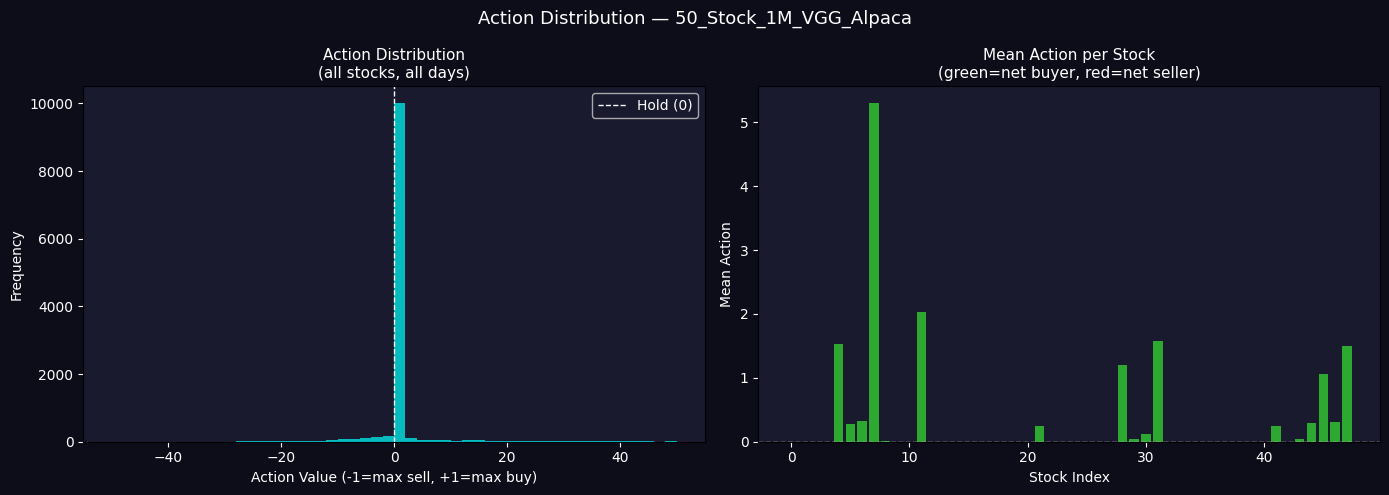

LOOK-AHEAD BIAS ANALYSIS

Pipeline:
  Polygon news date t  -> raw sentiment score for date t
  shift(1) applied     -> sentiment moved to date t+1
  Model trades date t  -> uses sentiment from date t-1

Result: NO look-ahead bias — news from date t informs
  trading decisions on date t+1 only.

First sentiment row per ticker is 0: True
CONFIRMED — shift(1) correctly applied

Sample rows for AAPL:
      date  tic  sentiment
2024-01-02 AAPL   0.000000
2024-01-03 AAPL  -0.037306
2024-01-04 AAPL  -0.149103
2024-01-05 AAPL  -0.128703
2024-01-08 AAPL  -0.050538
2024-01-09 AAPL   0.023295
2024-01-10 AAPL   0.062512
2024-01-11 AAPL  -0.011521
2024-01-12 AAPL   0.144166
2024-01-16 AAPL   0.235959
(First row should be 0.0 — no prior day sentiment)
Buy-and-Hold: 48 stocks, $20,833 per stock

  BUY-AND-HOLD METRICS
  Total Return (%)               25.53
  Sharpe Ratio                   1.437
  Max Drawdown (%)                -7.8
  Win Rate (%)                   56.97
  Avg Daily Return (%)       

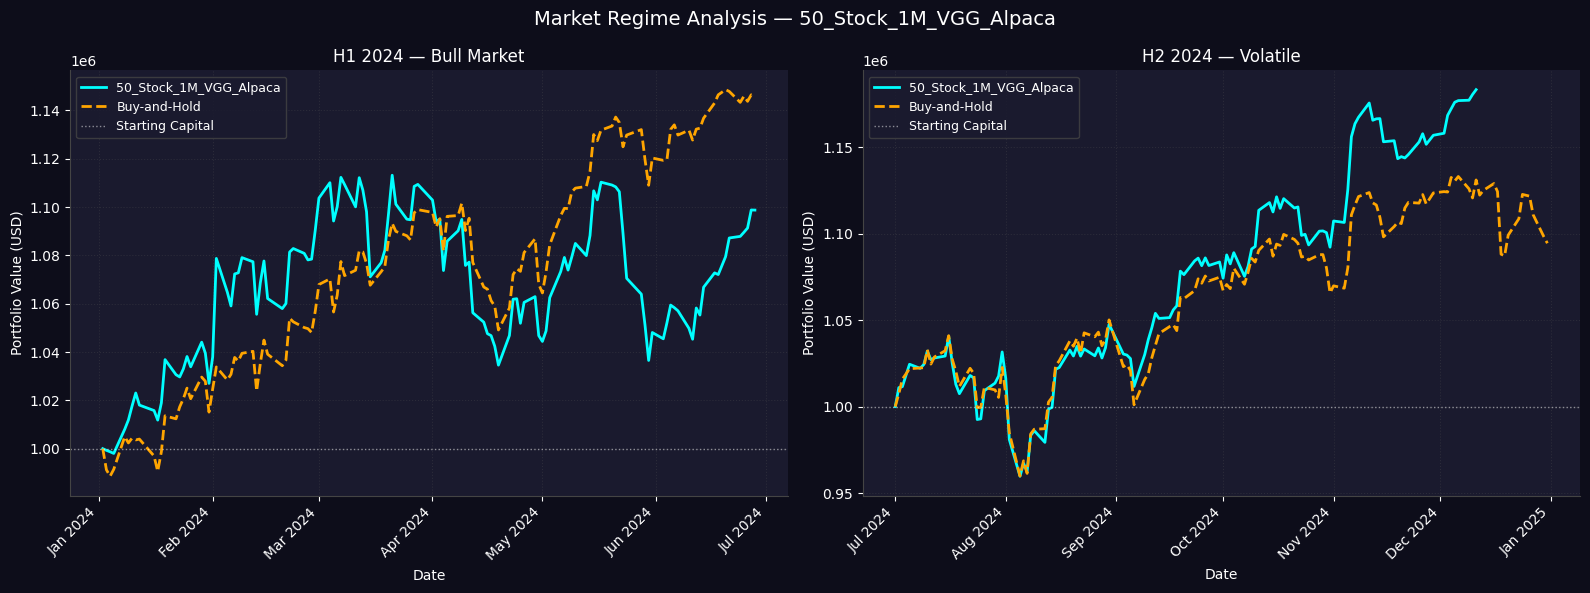

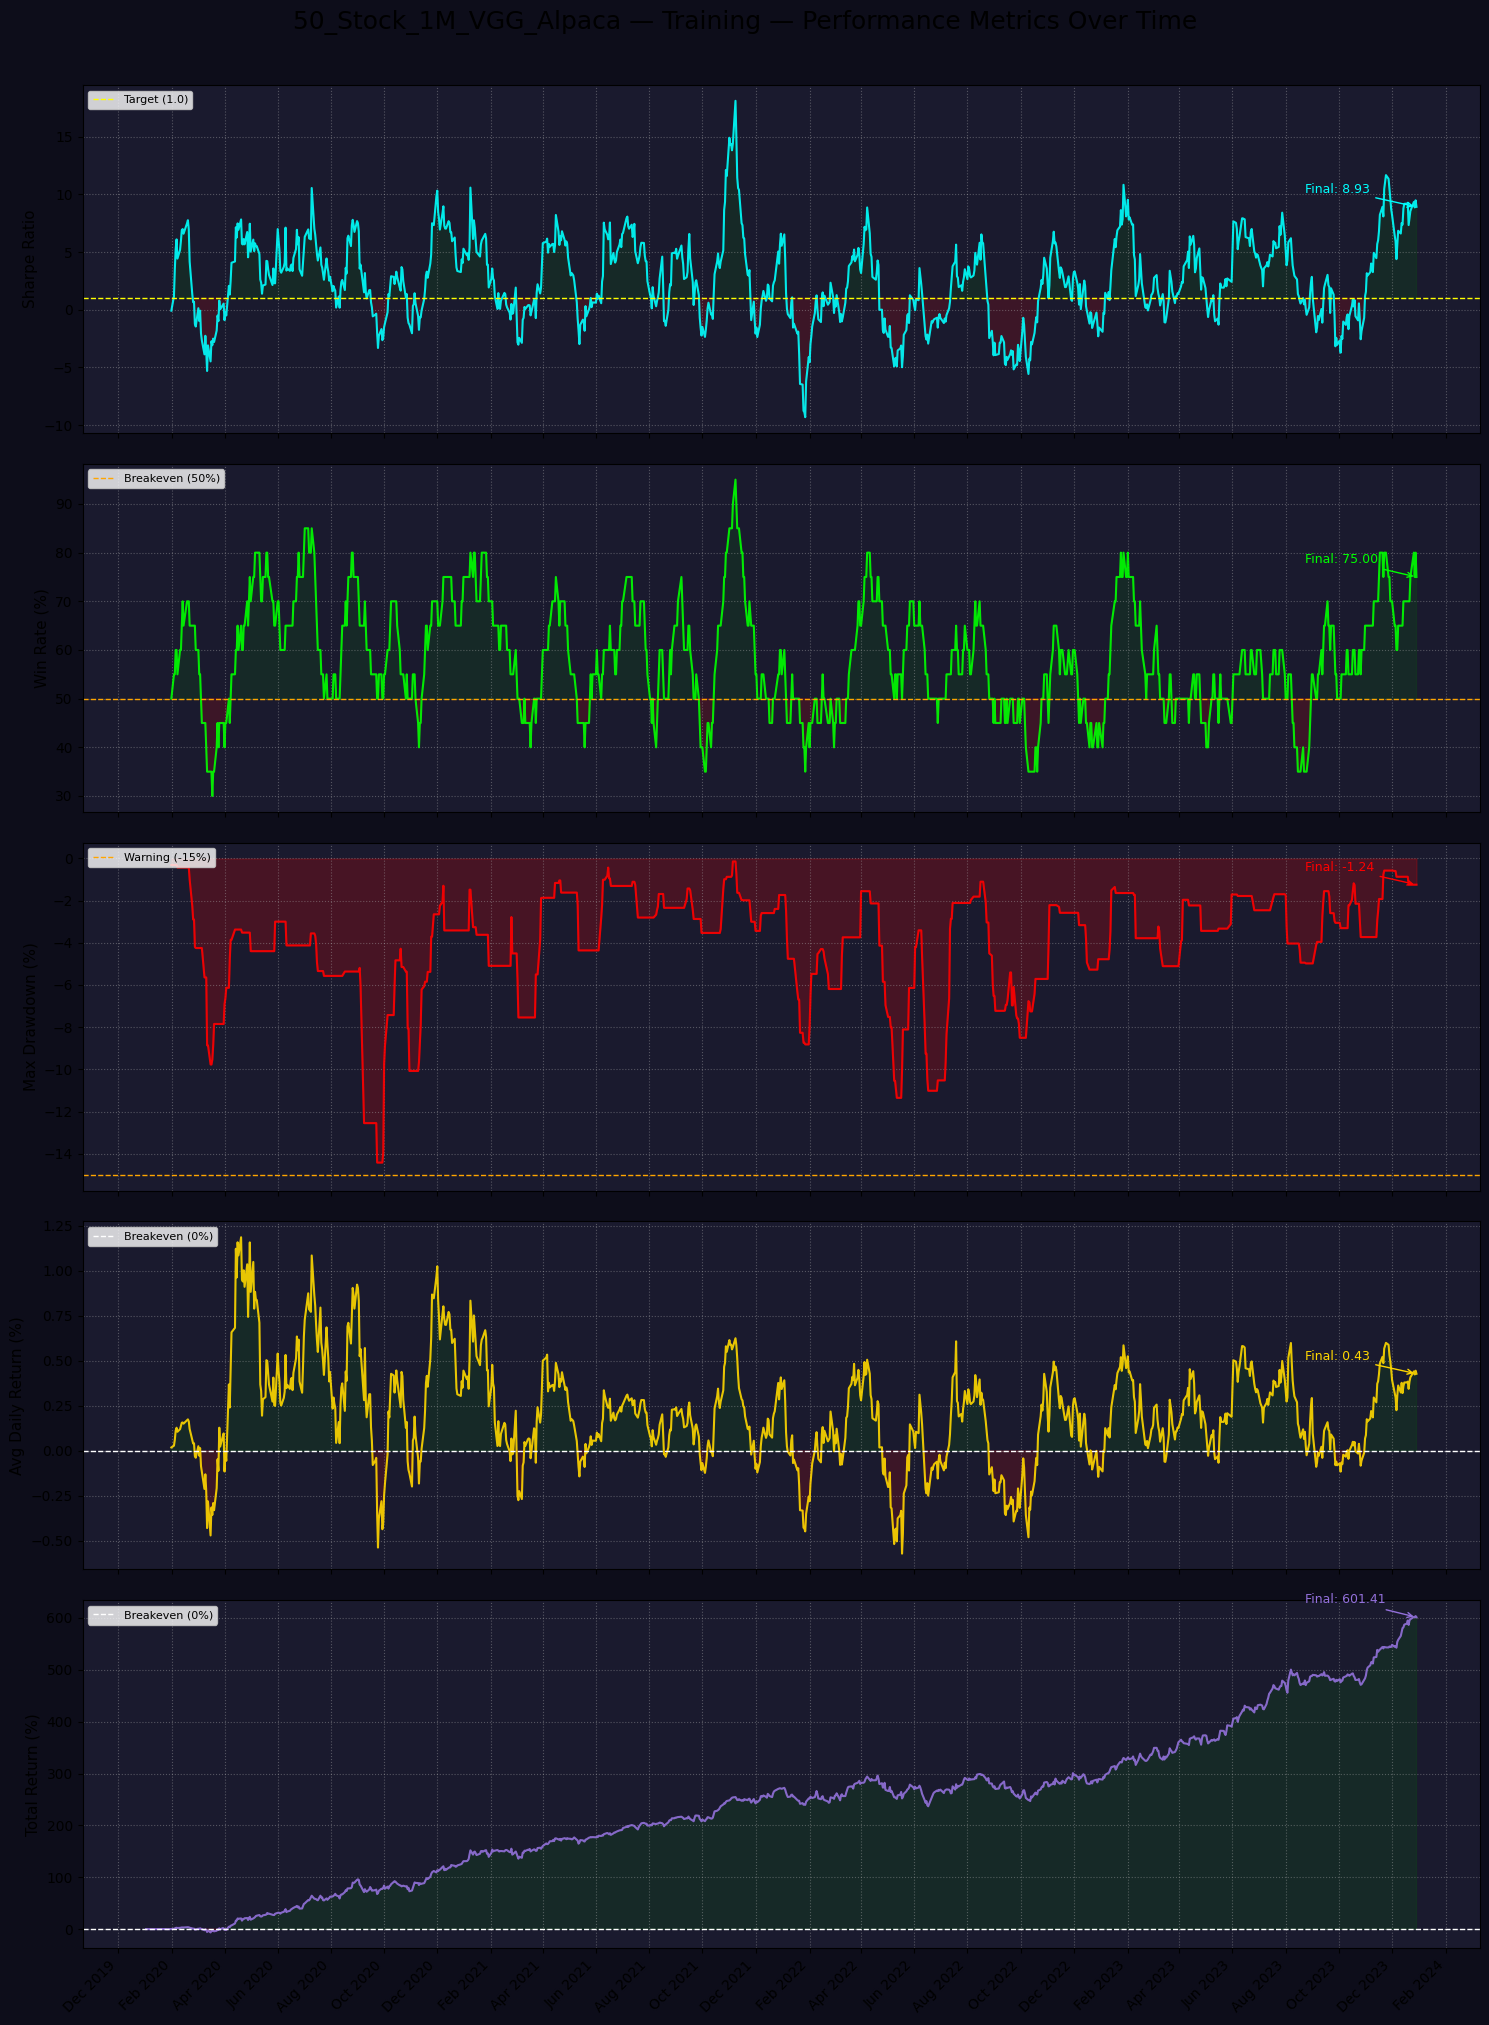


  50_STOCK_1M_VGG_ALPACA — TRAINING — FINAL METRIC VALUES
  Sharpe Ratio                   2.548  (avg)
  Win Rate (%)                  58.281  (avg)
  Max Drawdown (%)              -4.069  (avg)
  Avg Daily Return (%)           0.204  (avg)
  Total Return (%)             601.410  (final)


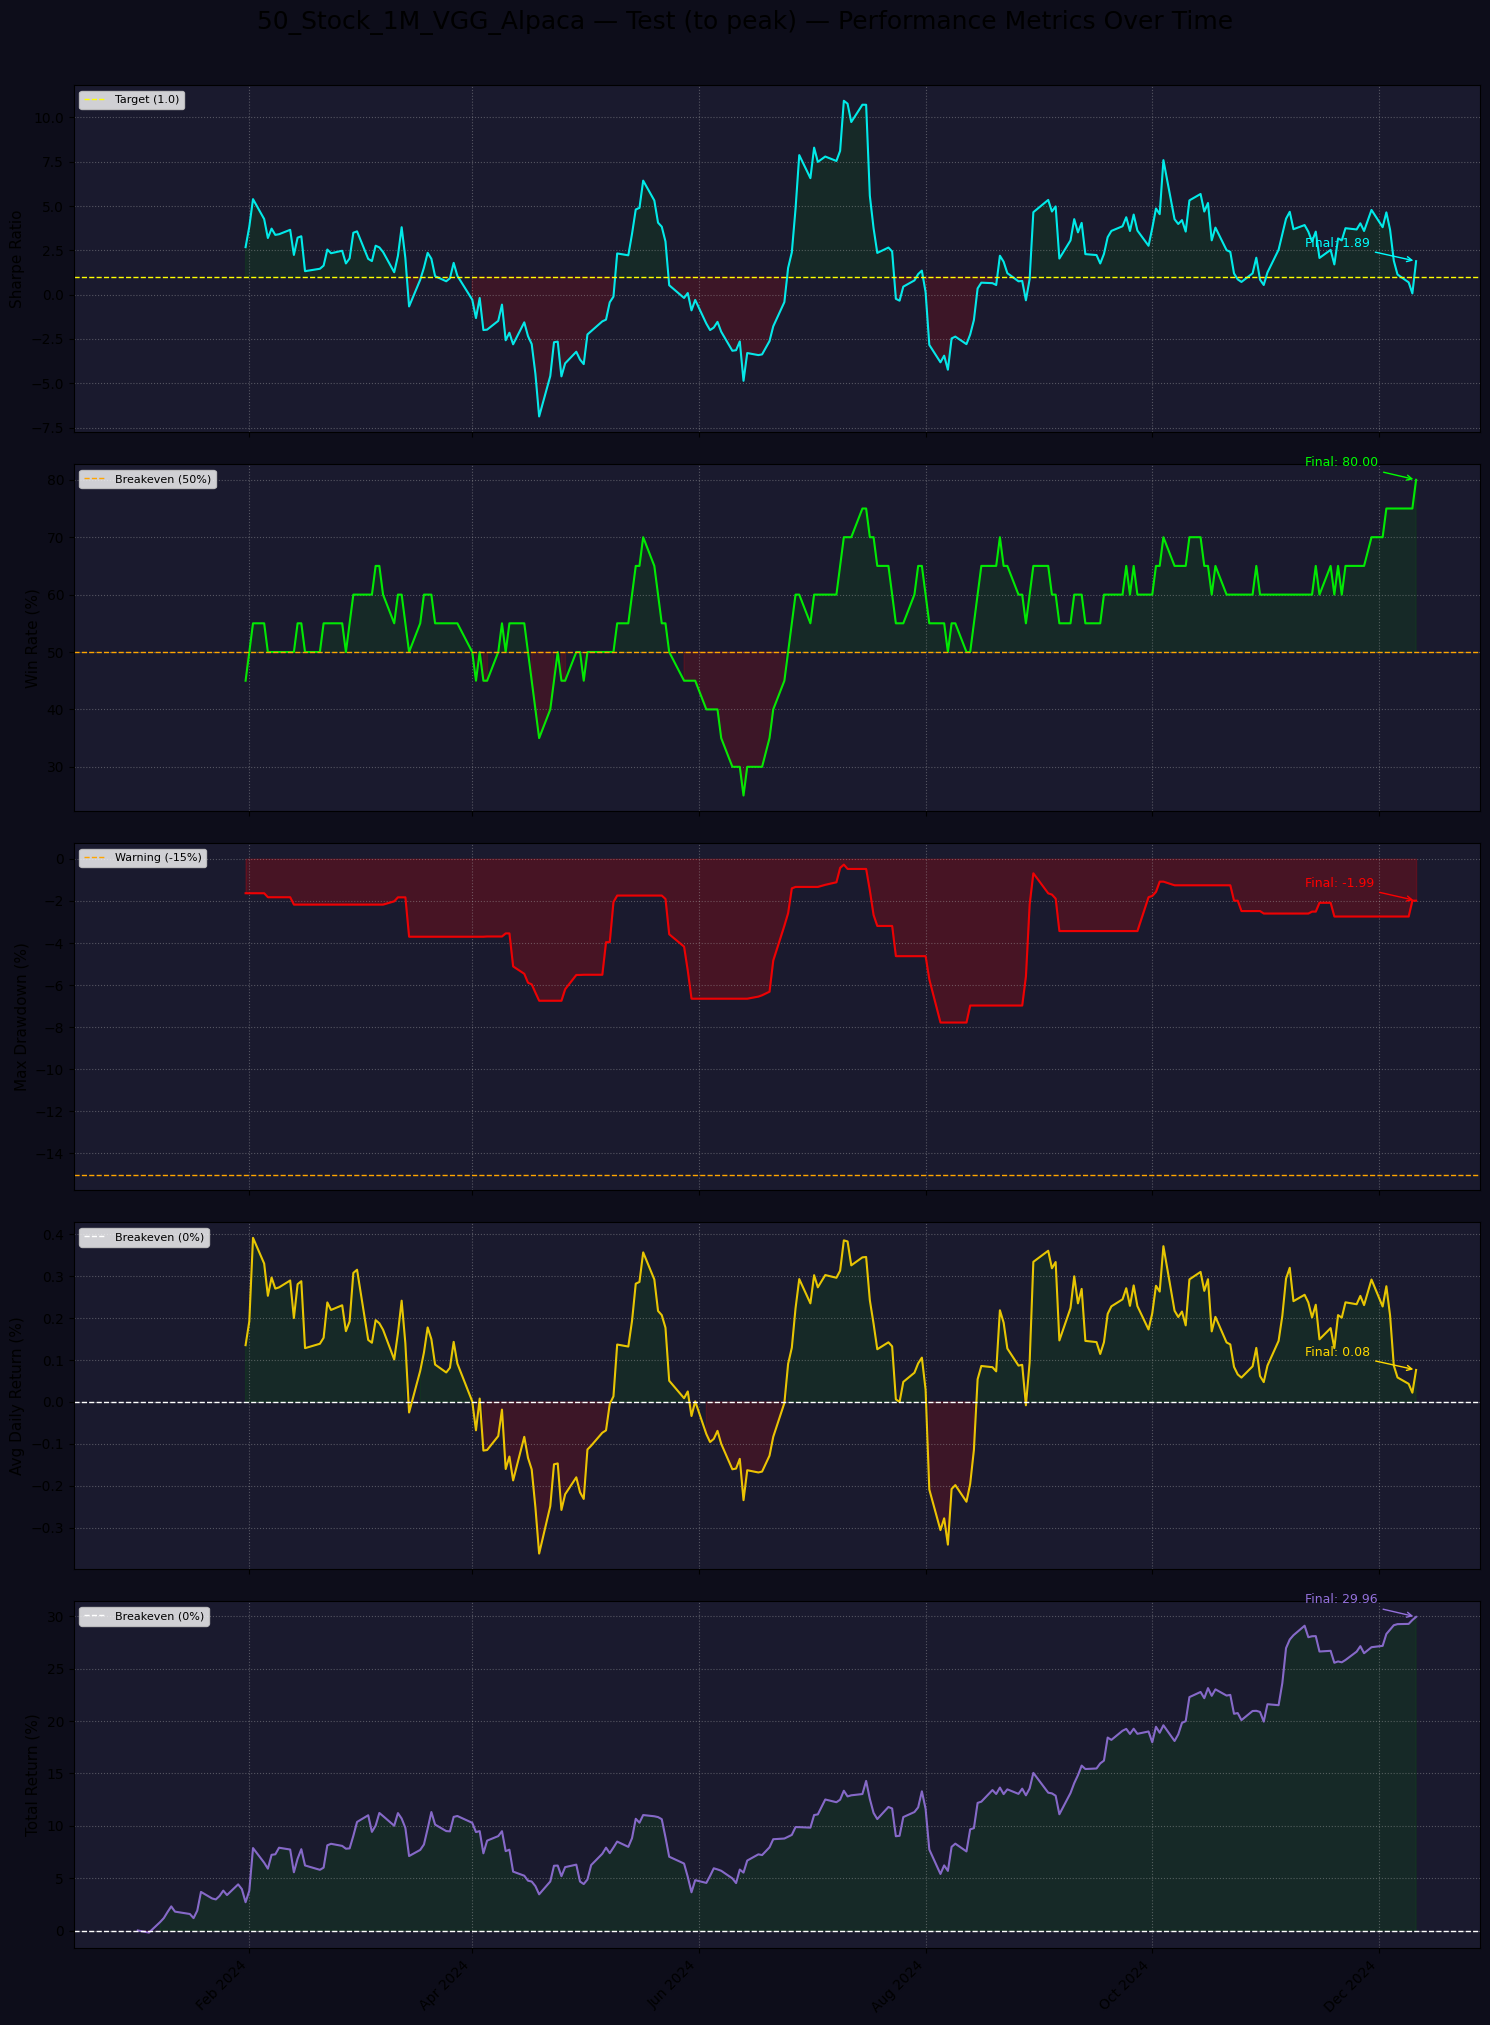


  50_STOCK_1M_VGG_ALPACA — TEST (TO PEAK) — FINAL METRIC VALUES
  Sharpe Ratio                   1.756  (avg)
  Win Rate (%)                  56.758  (avg)
  Max Drawdown (%)              -3.435  (avg)
  Avg Daily Return (%)           0.107  (avg)
  Total Return (%)              29.960  (final)

Pkl files saved: 6 files
Metrics summary: ./overlay_data/50_Stock_1M_VGG_Alpaca_metrics_summary.txt

  EVALUATION COMPLETE — 50_Stock_1M_VGG_Alpaca



In [19]:
# Just add the import at the top and run this cell
import sys
sys.path.append('.')
from utils import run_full_evaluation

results = run_full_evaluation(
    trained_model   = trained_vgg,    # already in memory
    e_train_gym     = e_train_gym,    # already in memory
    e_test_gym      = e_test_gym,     # already in memory
    df_test         = df_test,        # already in memory
    model_name      = 'VGG_Alpaca',
    universe        = '50_Stock',
    capital         = '1M',
    initial_capital = 1_000_000,
    has_sentiment   = True
)